In [1]:
"""
analyze_across_animals.py
Analyze landmark preferences across multiple animals and sessions

JSY, 11/2025
"""

import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import h5py
from glob import glob
from collections import defaultdict
import pandas as pd

# ============================================================================
# STEP 1: LOAD ALL ANIMALS DATA
# ============================================================================

def extract_animal_id(path):
    """
    Extract animal ID from folder path.
    Example: 'JSY054_ChronicImaging' → 'JSY054'
    """
    # Look for pattern like JSY### or similar
    match = re.search(r'(JSY\d+)', path)
    if match:
        return match.group(1)
    
    # Fallback: use the folder name containing 'ChronicImaging'
    for part in path.split(os.sep):
        if 'ChronicImaging' in part or 'Chronic' in part:
            # Extract first part before underscore
            return part.split('_')[0]
    
    return 'Unknown'

def extract_session_day(path):
    """
    Extract day number from folder path.
    Example: '251030_JSY_JSY054_SpMod_Day1' → 'Day1'
    """
    # Look for 'Day#' pattern
    match = re.search(r'Day(\d+)', path, re.IGNORECASE)
    if match:
        return f"Day{match.group(1)}"
    
    return None

def load_all_animals(parent_dir, landmark_pattern="*landmark_preferences.h5", 
                    preproc_pattern="*preproc.h5"):
    """
    Load all animal data from hierarchical directory structure.
    
    Directory structure:
    parent_dir/
      ├── JSY054_ChronicImaging/
      │   ├── 251030_JSY_JSY054_SpMod_Day1/
      │   │   └── TSeries-10302025-1512-001/
      │   │       └── Day1_landmark_preferences.h5
      │   ├── 251031_JSY_JSY054_SpMod_Day2/
      │   │   └── TSeries-.../
      │   │       └── Day2_landmark_preferences.h5
      
    Parameters:
    -----------
    parent_dir : str
        Root directory containing all animal folders
    landmark_pattern : str
        Pattern to match landmark preference files
    preproc_pattern : str
        Pattern to match preprocessed data files
    
    Returns:
    --------
    all_animals_landmark : dict
        Nested dict: {animal_id: {session_id: landmark_data}}
    all_animals_spatial : dict
        Nested dict: {animal_id: {session_id: spatial_data}}
    metadata : dict
        Information about animals and sessions
    """
    
    print("\n" + "="*70)
    print("LOADING ALL ANIMALS DATA")
    print("="*70)
    print(f"Scanning: {parent_dir}\n")
    
    # Find all landmark preference files
    landmark_files = glob(os.path.join(parent_dir, "**", landmark_pattern), recursive=True)
    preproc_files = glob(os.path.join(parent_dir, "**", preproc_pattern), recursive=True)
    
    print(f"Found {len(landmark_files)} landmark preference files")
    print(f"Found {len(preproc_files)} preprocessed data files\n")
    
    # Organize by animal and session
    all_animals_landmark = defaultdict(dict)
    all_animals_spatial = defaultdict(dict)
    file_mapping = defaultdict(lambda: defaultdict(dict))
    
    # Process landmark files
    for file_path in landmark_files:
        animal_id = extract_animal_id(file_path)
        session_id = extract_session_day(file_path)
        
        if session_id is None:
            print(f"WARNING: Could not extract session from {file_path}")
            continue
        
        print(f"  Loading: {animal_id} - {session_id}")
        print(f"    File: {os.path.basename(file_path)}")
        
        try:
            # Load landmark preference data
            with h5py.File(file_path, 'r') as f:
                session_data = {
                    'session_id': f.attrs.get('session_id', session_id),
                    'date': f.attrs.get('date', 'Unknown'),
                    'full_session': {},
                    'dynamics': {}
                }
                
                # Load full session results
                if 'full_session' in f:
                    full_grp = f['full_session']
                    for h5_layer_name in full_grp.keys():
                        layer_grp = full_grp[h5_layer_name]
                        
                        # Restore original layer name (L2_3 → L2/3)
                        if 'original_name' in layer_grp.attrs:
                            layer_name = str(layer_grp.attrs['original_name'])
                        else:
                            # Convert back from sanitized name
                            if '_' in h5_layer_name and h5_layer_name.startswith('L'):
                                parts = h5_layer_name.split('_')
                                if len(parts) == 2 and parts[1].isdigit():
                                    layer_name = f"{parts[0]}/{parts[1]}"
                                else:
                                    layer_name = h5_layer_name
                            else:
                                layer_name = h5_layer_name
                        
                        session_data['full_session'][layer_name] = {
                            'landmark_counts': layer_grp['landmark_counts'][:],
                            'landmark_proportions': layer_grp['landmark_proportions'][:],
                            'n_cells': layer_grp.attrs['n_cells'],
                            'preferred_landmarks': layer_grp['preferred_landmarks'][:],
                            'valid_cells': layer_grp['valid_cells'][:]
                        }
                
                # Load dynamics if available
                if 'dynamics' in f:
                    dyn_grp = f['dynamics']
                    session_data['dynamics']['n_blocks'] = dyn_grp.attrs.get('n_blocks', 0)
                    session_data['dynamics']['trials_per_block'] = dyn_grp.attrs.get('trials_per_block', 30)
                    if 'landmark_positions' in dyn_grp:
                        session_data['dynamics']['landmark_positions'] = dyn_grp['landmark_positions'][:]
            
            all_animals_landmark[animal_id][session_id] = session_data
            file_mapping[animal_id][session_id]['landmark'] = file_path
            
        except Exception as e:
            print(f"    ERROR loading landmark data: {e}")
            continue
    
    # Process preproc files
    print("\n" + "-"*70)
    print("Loading spatial data from preproc files...")
    print("-"*70 + "\n")
    
    for file_path in preproc_files:
        animal_id = extract_animal_id(file_path)
        session_id = extract_session_day(file_path)
        
        if session_id is None:
            continue
        
        # Only load if we have corresponding landmark data
        if animal_id not in all_animals_landmark or session_id not in all_animals_landmark[animal_id]:
            continue
        
        print(f"  Loading spatial: {animal_id} - {session_id}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                spatial_data = {
                    'normalized_spatial_activity': f['norm_spatial_activity'][:],
                    'spatial_activity': f['spatial_activity'][:] if 'spatial_activity' in f else None,
                    'bin_centers': f['bin_centers'][:],
                    'reliable_cells': f['combined_reliable'][:] if 'combined_reliable' in f else f['reliable_cells'][:]
                }
            
            all_animals_spatial[animal_id][session_id] = spatial_data
            file_mapping[animal_id][session_id]['preproc'] = file_path
            
        except Exception as e:
            print(f"    ERROR loading spatial data: {e}")
            continue
    
    # Create metadata summary
    metadata = {
        'animals': list(all_animals_landmark.keys()),
        'n_animals': len(all_animals_landmark),
        'sessions_per_animal': {},
        'all_sessions': set(),
        'file_mapping': dict(file_mapping)
    }
    
    for animal_id in all_animals_landmark.keys():
        sessions = sorted(all_animals_landmark[animal_id].keys())
        metadata['sessions_per_animal'][animal_id] = sessions
        metadata['all_sessions'].update(sessions)
    
    metadata['all_sessions'] = sorted(list(metadata['all_sessions']))
    
    # Print summary
    print("\n" + "="*70)
    print("DATA LOADING SUMMARY")
    print("="*70)
    print(f"\nAnimals loaded: {metadata['n_animals']}")
    for animal_id in metadata['animals']:
        sessions = metadata['sessions_per_animal'][animal_id]
        print(f"  {animal_id}: {len(sessions)} sessions - {', '.join(sessions)}")
    
    print(f"\nAll unique sessions: {', '.join(metadata['all_sessions'])}")
    print("="*70 + "\n")
    
    return dict(all_animals_landmark), dict(all_animals_spatial), metadata


# ============================================================================
# STEP 2: CREATE HEATMAP VISUALIZATIONS
# ============================================================================

def create_session_averaged_heatmaps(all_animals_landmark, metadata, 
                                    landmark_positions=[30, 60, 90, 120],
                                    save_path=None):
    """
    Create heatmaps showing landmark preferences by layer.
    
    Generates:
    1. Grand average (all animals, all sessions)
    2. Session-specific (averaged across animals for each session)
    
    Parameters:
    -----------
    all_animals_landmark : dict
        Nested dict with landmark data
    metadata : dict
        Metadata about animals and sessions
    landmark_positions : list
        Positions of landmarks in cm
    save_path : str, optional
        Directory to save figures
    """
    
    print("\n" + "="*70)
    print("CREATING HEATMAP VISUALIZATIONS")
    print("="*70)
    
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    n_landmarks = len(landmark_positions)
    all_sessions = metadata['all_sessions']
    
    # Collect all data for grand average
    grand_data = defaultdict(lambda: defaultdict(list))
    
    for animal_id, sessions in all_animals_landmark.items():
        for session_id, session_data in sessions.items():
            for layer_name, layer_data in session_data['full_session'].items():
                if layer_name in layer_order:
                    grand_data[layer_name]['proportions'].append(layer_data['landmark_proportions'])
                    grand_data[layer_name]['counts'].append(layer_data['landmark_counts'])
    
    # Calculate grand average
    grand_avg = np.zeros((len(layer_order), n_landmarks))
    grand_sem = np.zeros((len(layer_order), n_landmarks))
    grand_counts = np.zeros((len(layer_order), n_landmarks), dtype=int)
    
    for i, layer_name in enumerate(layer_order):
        if layer_name in grand_data and len(grand_data[layer_name]['proportions']) > 0:
            props = np.array(grand_data[layer_name]['proportions'])
            counts = np.array(grand_data[layer_name]['counts'])
            
            grand_avg[i, :] = np.mean(props, axis=0)
            grand_sem[i, :] = stats.sem(props, axis=0) if len(props) > 1 else np.zeros(n_landmarks)
            grand_counts[i, :] = np.sum(counts, axis=0)
    
    # Create figure with grand average + session-specific panels
    n_panels = len(all_sessions) + 1  # +1 for grand average
    n_cols = min(3, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten() if n_panels > 1 else [axes]
    
    # Plot grand average in first panel
    ax = axes[0]
    im = ax.imshow(grand_avg, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(n_landmarks))
    ax.set_yticks(np.arange(len(layer_order)))
    ax.set_xticklabels([f"L{i+1}\n({landmark_positions[i]:.0f}cm)" for i in range(n_landmarks)])
    ax.set_yticklabels(layer_order)
    
    # Add text annotations
    for i in range(len(layer_order)):
        for j in range(n_landmarks):
            text_str = f'{grand_avg[i, j]:.2f}\n±{grand_sem[i, j]:.2f}\n(n={grand_counts[i, j]})'
            ax.text(j, i, text_str, ha="center", va="center", color="black", fontsize=9)
    
    ax.set_xlabel('Landmark', fontsize=11)
    ax.set_ylabel('Layer', fontsize=11)
    ax.set_title('Grand Average\n(All Animals, All Sessions)', fontsize=12, fontweight='bold')
    
    # Plot session-specific heatmaps
    for panel_idx, session_id in enumerate(all_sessions, start=1):
        ax = axes[panel_idx]
        
        # Collect data for this session
        session_data_by_layer = defaultdict(lambda: {'proportions': [], 'counts': []})
        
        for animal_id, sessions in all_animals_landmark.items():
            if session_id in sessions:
                for layer_name, layer_data in sessions[session_id]['full_session'].items():
                    if layer_name in layer_order:
                        session_data_by_layer[layer_name]['proportions'].append(layer_data['landmark_proportions'])
                        session_data_by_layer[layer_name]['counts'].append(layer_data['landmark_counts'])
        
        # Calculate averages
        session_avg = np.zeros((len(layer_order), n_landmarks))
        session_sem = np.zeros((len(layer_order), n_landmarks))
        session_counts = np.zeros((len(layer_order), n_landmarks), dtype=int)
        
        for i, layer_name in enumerate(layer_order):
            if layer_name in session_data_by_layer and len(session_data_by_layer[layer_name]['proportions']) > 0:
                props = np.array(session_data_by_layer[layer_name]['proportions'])
                counts = np.array(session_data_by_layer[layer_name]['counts'])
                
                session_avg[i, :] = np.mean(props, axis=0)
                session_sem[i, :] = stats.sem(props, axis=0) if len(props) > 1 else np.zeros(n_landmarks)
                session_counts[i, :] = np.sum(counts, axis=0)
        
        # Plot
        im = ax.imshow(session_avg, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        
        ax.set_xticks(np.arange(n_landmarks))
        ax.set_yticks(np.arange(len(layer_order)))
        ax.set_xticklabels([f"L{i+1}\n({landmark_positions[i]:.0f}cm)" for i in range(n_landmarks)])
        ax.set_yticklabels(layer_order)
        
        # Add text annotations
        n_animals_this_session = len([a for a in all_animals_landmark.keys() if session_id in all_animals_landmark[a]])
        
        for i in range(len(layer_order)):
            for j in range(n_landmarks):
                if session_counts[i, j] > 0:
                    text_str = f'{session_avg[i, j]:.2f}\n±{session_sem[i, j]:.2f}\n(n={session_counts[i, j]})'
                else:
                    text_str = 'N/A'
                ax.text(j, i, text_str, ha="center", va="center", color="black", fontsize=9)
        
        ax.set_xlabel('Landmark', fontsize=11)
        ax.set_ylabel('Layer', fontsize=11)
        ax.set_title(f'{session_id}\n({n_animals_this_session} animals)', fontsize=12, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_panels, len(axes)):
        axes[idx].axis('off')
    
    # Add colorbar
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Proportion of Cells')
    
    plt.tight_layout()
    
    if save_path:
        fig_path = os.path.join(save_path, 'heatmap_evolution_across_sessions.png')
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(fig_path)}")
    
    plt.show()
    
    return fig


# ============================================================================
# STEP 3: CREATE VIOLIN PLOTS
# ============================================================================

def create_violin_plots(all_animals_landmark, metadata, landmark_positions=[30, 60, 90, 120],
                       save_path=None):
    """
    Create violin plots showing distribution of landmark preferences by layer.
    
    Parameters:
    -----------
    all_animals_landmark : dict
        Nested dict with landmark data
    metadata : dict
        Metadata about animals and sessions
    landmark_positions : list
        Positions of landmarks in cm
    save_path : str, optional
        Directory to save figure
    """
    
    print("\n" + "="*70)
    print("CREATING VIOLIN PLOTS")
    print("="*70)
    
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    n_landmarks = len(landmark_positions)
    
    # Collect all data points (each = one session from one animal)
    data_for_plotting = defaultdict(lambda: defaultdict(list))
    
    for animal_id, sessions in all_animals_landmark.items():
        for session_id, session_data in sessions.items():
            for layer_name, layer_data in session_data['full_session'].items():
                if layer_name in layer_order:
                    proportions = layer_data['landmark_proportions']
                    for lm_idx, prop in enumerate(proportions):
                        data_for_plotting[layer_name][lm_idx].append(prop)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, layer_name in enumerate(layer_order):
        ax = axes[ax_idx]
        
        if layer_name not in data_for_plotting:
            ax.text(0.5, 0.5, f'{layer_name}: No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12)
            continue
        
        # Prepare data for violin plot
        plot_data = []
        positions = []
        
        for lm_idx in range(n_landmarks):
            if lm_idx in data_for_plotting[layer_name]:
                plot_data.append(data_for_plotting[layer_name][lm_idx])
                positions.append(lm_idx)
        
        if len(plot_data) == 0:
            continue
        
        # Create violin plot
        parts = ax.violinplot(plot_data, positions=positions, widths=0.7,
                             showmeans=True, showmedians=True)
        
        # Customize violin colors
        colors = plt.cm.Set1(np.linspace(0, 1, n_landmarks))
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        
        # Overlay individual points
        for lm_idx, data_points in enumerate(plot_data):
            x = np.random.normal(positions[lm_idx], 0.04, size=len(data_points))
            ax.scatter(x, data_points, alpha=0.4, s=30, color='black', zorder=10)
        
        # Format
        ax.set_xticks(range(n_landmarks))
        ax.set_xticklabels([f"L{i+1}\n({landmark_positions[i]:.0f}cm)" for i in range(n_landmarks)])
        ax.set_ylabel('Proportion of Cells', fontsize=11)
        ax.set_title(f'{layer_name}', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add sample size
        n_points = sum(len(d) for d in plot_data)
        ax.text(0.02, 0.98, f'n = {n_points} observations', transform=ax.transAxes,
               va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    fig.suptitle('Landmark Preference Distributions by Layer\n(All Animals, All Sessions)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        fig_path = os.path.join(save_path, 'violin_plots_by_layer.png')
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(fig_path)}")
    
    plt.show()
    
    return fig


# ============================================================================
# STEP 4: EXPORT COMBINED SPATIAL DATA FOR NEURAL RESPONSE PLOTS
# ============================================================================

def export_combined_spatial_data(all_animals_spatial, all_animals_landmark, metadata,
                                landmark_positions=[30, 60, 90, 120],
                                save_path=None):
    """
    Export combined spatial activity data for creating neural response plots.
    Combines all cells from all animals for each layer-session combination.
    
    Parameters:
    -----------
    all_animals_spatial : dict
        Spatial activity data
    all_animals_landmark : dict
        Landmark preference data (for layer assignments)
    metadata : dict
        Metadata
    landmark_positions : list
        Landmark positions
    save_path : str, optional
        Path to save combined data
    
    Returns:
    --------
    combined_data : dict
        Combined spatial data organized by session and layer
    """
    
    print("\n" + "="*70)
    print("EXPORTING COMBINED SPATIAL DATA")
    print("="*70)
    
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    all_sessions = metadata['all_sessions']
    
    combined_data = {}
    
    for session_id in all_sessions:
        print(f"\nProcessing {session_id}...")
        combined_data[session_id] = {}
        
        for layer_name in layer_order:
            # Collect cells from all animals for this layer-session combination
            all_cells_activity = []
            all_cells_reliable = []
            bin_centers_ref = None
            
            for animal_id in metadata['animals']:
                # Check if this animal has this session
                if session_id not in all_animals_spatial[animal_id]:
                    continue
                
                if session_id not in all_animals_landmark[animal_id]:
                    continue
                
                # Get spatial data
                spatial_data = all_animals_spatial[animal_id][session_id]
                landmark_data = all_animals_landmark[animal_id][session_id]
                
                # Check if this layer exists
                if layer_name not in landmark_data['full_session']:
                    continue
                
                # Get cells belonging to this layer
                layer_info = landmark_data['full_session'][layer_name]
                layer_cell_indices = layer_info['valid_cells']
                
                # Extract activity for these cells
                cell_activity = spatial_data['normalized_spatial_activity'][layer_cell_indices, :, :]
                cell_reliable = spatial_data['reliable_cells'][layer_cell_indices]
                
                all_cells_activity.append(cell_activity)
                all_cells_reliable.append(cell_reliable)
                
                # Store bin_centers (should be same for all)
                if bin_centers_ref is None:
                    bin_centers_ref = spatial_data['bin_centers']
            
            # Combine all cells
            if len(all_cells_activity) > 0:
                combined_activity = np.concatenate(all_cells_activity, axis=0)
                combined_reliable = np.concatenate(all_cells_reliable, axis=0)
                
                combined_data[session_id][layer_name] = {
                    'normalized_spatial_activity': combined_activity,
                    'reliable_cells': combined_reliable,
                    'bin_centers': bin_centers_ref,
                    'n_cells': combined_activity.shape[0],
                    'n_animals': len(all_cells_activity)
                }
                
                print(f"  {layer_name}: {combined_activity.shape[0]} cells from {len(all_cells_activity)} animals")
            else:
                print(f"  {layer_name}: No data")
    
    # Save to HDF5
    if save_path:
        h5_path = os.path.join(save_path, 'combined_spatial_data_across_animals.h5')
        
        print(f"\nSaving combined data to: {os.path.basename(h5_path)}")
        
        with h5py.File(h5_path, 'w') as f:
            # Save metadata
            f.attrs['landmark_positions'] = landmark_positions
            f.attrs['sessions'] = ','.join(all_sessions)
            f.attrs['layers'] = ','.join(layer_order)
            f.attrs['n_animals'] = metadata['n_animals']
            
            # Save data for each session
            for session_id, session_data in combined_data.items():
                session_grp = f.create_group(session_id)
                
                for layer_name, layer_data in session_data.items():
                    # Sanitize layer name for HDF5
                    safe_layer_name = layer_name.replace('/', '_')
                    layer_grp = session_grp.create_group(safe_layer_name)
                    
                    layer_grp.attrs['original_name'] = layer_name
                    layer_grp.attrs['n_cells'] = layer_data['n_cells']
                    layer_grp.attrs['n_animals'] = layer_data['n_animals']
                    
                    layer_grp.create_dataset('normalized_spatial_activity', 
                                            data=layer_data['normalized_spatial_activity'],
                                            compression='gzip')
                    layer_grp.create_dataset('reliable_cells', 
                                            data=layer_data['reliable_cells'])
                    layer_grp.create_dataset('bin_centers', 
                                            data=layer_data['bin_centers'])
        
        print(f"✓ Saved: {h5_path}")
    
    return combined_data


# ============================================================================
# STEP 5: CREATE ANIMAL-SPECIFIC HEATMAPS (SUPPLEMENTARY)
# ============================================================================

def create_animal_specific_heatmaps(all_animals_landmark, metadata,
                                   landmark_positions=[30, 60, 90, 120],
                                   save_path=None):
    """
    Create one heatmap per animal (averaged across all sessions).
    
    Parameters:
    -----------
    all_animals_landmark : dict
        Landmark data
    metadata : dict
        Metadata
    landmark_positions : list
        Landmark positions
    save_path : str, optional
        Directory to save figures
    """
    
    print("\n" + "="*70)
    print("CREATING ANIMAL-SPECIFIC HEATMAPS")
    print("="*70)
    
    layer_order = ['L2/3', 'L4', 'L5', 'L6']
    n_landmarks = len(landmark_positions)
    n_animals = len(metadata['animals'])
    
    # Create figure
    n_cols = min(3, n_animals)
    n_rows = int(np.ceil(n_animals / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten() if n_animals > 1 else [axes]
    
    for ax_idx, animal_id in enumerate(metadata['animals']):
        ax = axes[ax_idx]
        
        # Collect data for this animal (average across sessions)
        animal_data = defaultdict(lambda: {'proportions': [], 'counts': []})
        
        for session_id, session_data in all_animals_landmark[animal_id].items():
            for layer_name, layer_data in session_data['full_session'].items():
                if layer_name in layer_order:
                    animal_data[layer_name]['proportions'].append(layer_data['landmark_proportions'])
                    animal_data[layer_name]['counts'].append(layer_data['landmark_counts'])
        
        # Calculate averages
        animal_avg = np.zeros((len(layer_order), n_landmarks))
        animal_counts = np.zeros((len(layer_order), n_landmarks), dtype=int)
        
        for i, layer_name in enumerate(layer_order):
            if layer_name in animal_data and len(animal_data[layer_name]['proportions']) > 0:
                props = np.array(animal_data[layer_name]['proportions'])
                counts = np.array(animal_data[layer_name]['counts'])
                
                animal_avg[i, :] = np.mean(props, axis=0)
                animal_counts[i, :] = np.sum(counts, axis=0)
        
        # Plot
        im = ax.imshow(animal_avg, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        
        ax.set_xticks(np.arange(n_landmarks))
        ax.set_yticks(np.arange(len(layer_order)))
        ax.set_xticklabels([f"L{i+1}\n({landmark_positions[i]:.0f}cm)" for i in range(n_landmarks)])
        ax.set_yticklabels(layer_order)
        
        # Add text annotations
        for i in range(len(layer_order)):
            for j in range(n_landmarks):
                if animal_counts[i, j] > 0:
                    text_str = f'{animal_avg[i, j]:.2f}\n(n={animal_counts[i, j]})'
                else:
                    text_str = 'N/A'
                ax.text(j, i, text_str, ha="center", va="center", color="black", fontsize=9)
        
        n_sessions = len(all_animals_landmark[animal_id])
        ax.set_xlabel('Landmark', fontsize=11)
        ax.set_ylabel('Layer', fontsize=11)
        ax.set_title(f'{animal_id}\n({n_sessions} sessions)', fontsize=12, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(n_animals, len(axes)):
        axes[idx].axis('off')
    
    # Add colorbar
    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Proportion of Cells')
    
    fig.suptitle('Animal-Specific Landmark Preferences\n(Averaged Across All Sessions)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        fig_path = os.path.join(save_path, 'animal_specific_heatmaps.png')
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(fig_path)}")
    
    plt.show()
    
    return fig



In [2]:

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_across_animals_analysis(parent_dir, save_path=None, 
                                landmark_positions=[30, 60, 90, 120]):
    """
    Complete workflow for across-animals analysis.
    
    Parameters:
    -----------
    parent_dir : str
        Root directory containing all animal folders
    save_path : str, optional
        Directory to save outputs
    landmark_positions : list
        Positions of landmarks in cm
    
    Returns:
    --------
    results : dict
        All analysis results
    """
    
    print("\n" + "="*80)
    print("ACROSS-ANIMALS LANDMARK PREFERENCE ANALYSIS")
    print("="*80)
    print(f"Parent directory: {parent_dir}")
    if save_path:
        print(f"Save directory: {save_path}")
    print("="*80)
    
    # Create save directory if needed
    if save_path and not os.path.exists(save_path):
        os.makedirs(save_path)
        print(f"Created directory: {save_path}\n")
    
    # Step 1: Load all data
    all_animals_landmark, all_animals_spatial, metadata = load_all_animals(parent_dir)
    
    if metadata['n_animals'] == 0:
        print("ERROR: No animals found!")
        return None
    
    # Step 2: Create heatmaps
    fig_heatmaps = create_session_averaged_heatmaps(
        all_animals_landmark, metadata, landmark_positions, save_path
    )
    
    # Step 3: Create violin plots
    fig_violin = create_violin_plots(
        all_animals_landmark, metadata, landmark_positions, save_path
    )
    
    # Step 4: Export combined spatial data
    combined_spatial = export_combined_spatial_data(
        all_animals_spatial, all_animals_landmark, metadata, 
        landmark_positions, save_path
    )
    
    # Step 5: Create animal-specific heatmaps
    fig_animal_specific = create_animal_specific_heatmaps(
        all_animals_landmark, metadata, landmark_positions, save_path
    )
    
    # Compile results
    results = {
        'all_animals_landmark': all_animals_landmark,
        'all_animals_spatial': all_animals_spatial,
        'combined_spatial': combined_spatial,
        'metadata': metadata,
        'figures': {
            'heatmaps': fig_heatmaps,
            'violin': fig_violin,
            'animal_specific': fig_animal_specific
        }
    }
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nGenerated figures:")
    print(f"  1. Heatmap evolution (Grand + Session-specific)")
    print(f"  2. Violin plots (Population distributions)")
    print(f"  3. Animal-specific heatmaps (Supplementary)")
    print(f"\nExported data:")
    print(f"  - Combined spatial data for neural response plots")
    if save_path:
        print(f"  - Saved to: {save_path}")
    print("="*80 + "\n")
    
    return results


# ============================================================================
# USAGE EXAMPLE
# ============================================================================



ACROSS-ANIMALS LANDMARK PREFERENCE ANALYSIS
Parent directory: D:\V1_SpatialModulation\2p\V1_prism
Save directory: D:\V1_SpatialModulation\2p\V1_prism\across_animals_analysis

LOADING ALL ANIMALS DATA
Scanning: D:\V1_SpatialModulation\2p\V1_prism

Found 12 landmark preference files
Found 44 preprocessed data files

  Loading: JSY052 - Day1
    File: Day7_landmark_preferences.h5
  Loading: JSY052 - Day2
    File: Day2_landmark_preferences.h5
  Loading: JSY052 - Day3
    File: Day3_landmark_preferences.h5
  Loading: JSY052 - Day4
    File: Day4_landmark_preferences.h5
  Loading: JSY052 - Day5
    File: Day5_landmark_preferences.h5
  Loading: JSY054 - Day1
    File: Day1_landmark_preferences.h5
  Loading: JSY054 - Day2
    File: Day2_landmark_preferences.h5
  Loading: JSY054 - Day3
    File: Day3_landmark_preferences.h5
  Loading: JSY054 - Day4
    File: Day4_landmark_preferences.h5
  Loading: JSY054 - Day5
    File: Day5_landmark_preferences.h5
  Loading: JSY054 - Day6
    File: Day6_lan

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_45108\1017038001.py:380: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: heatmap_evolution_across_sessions.png


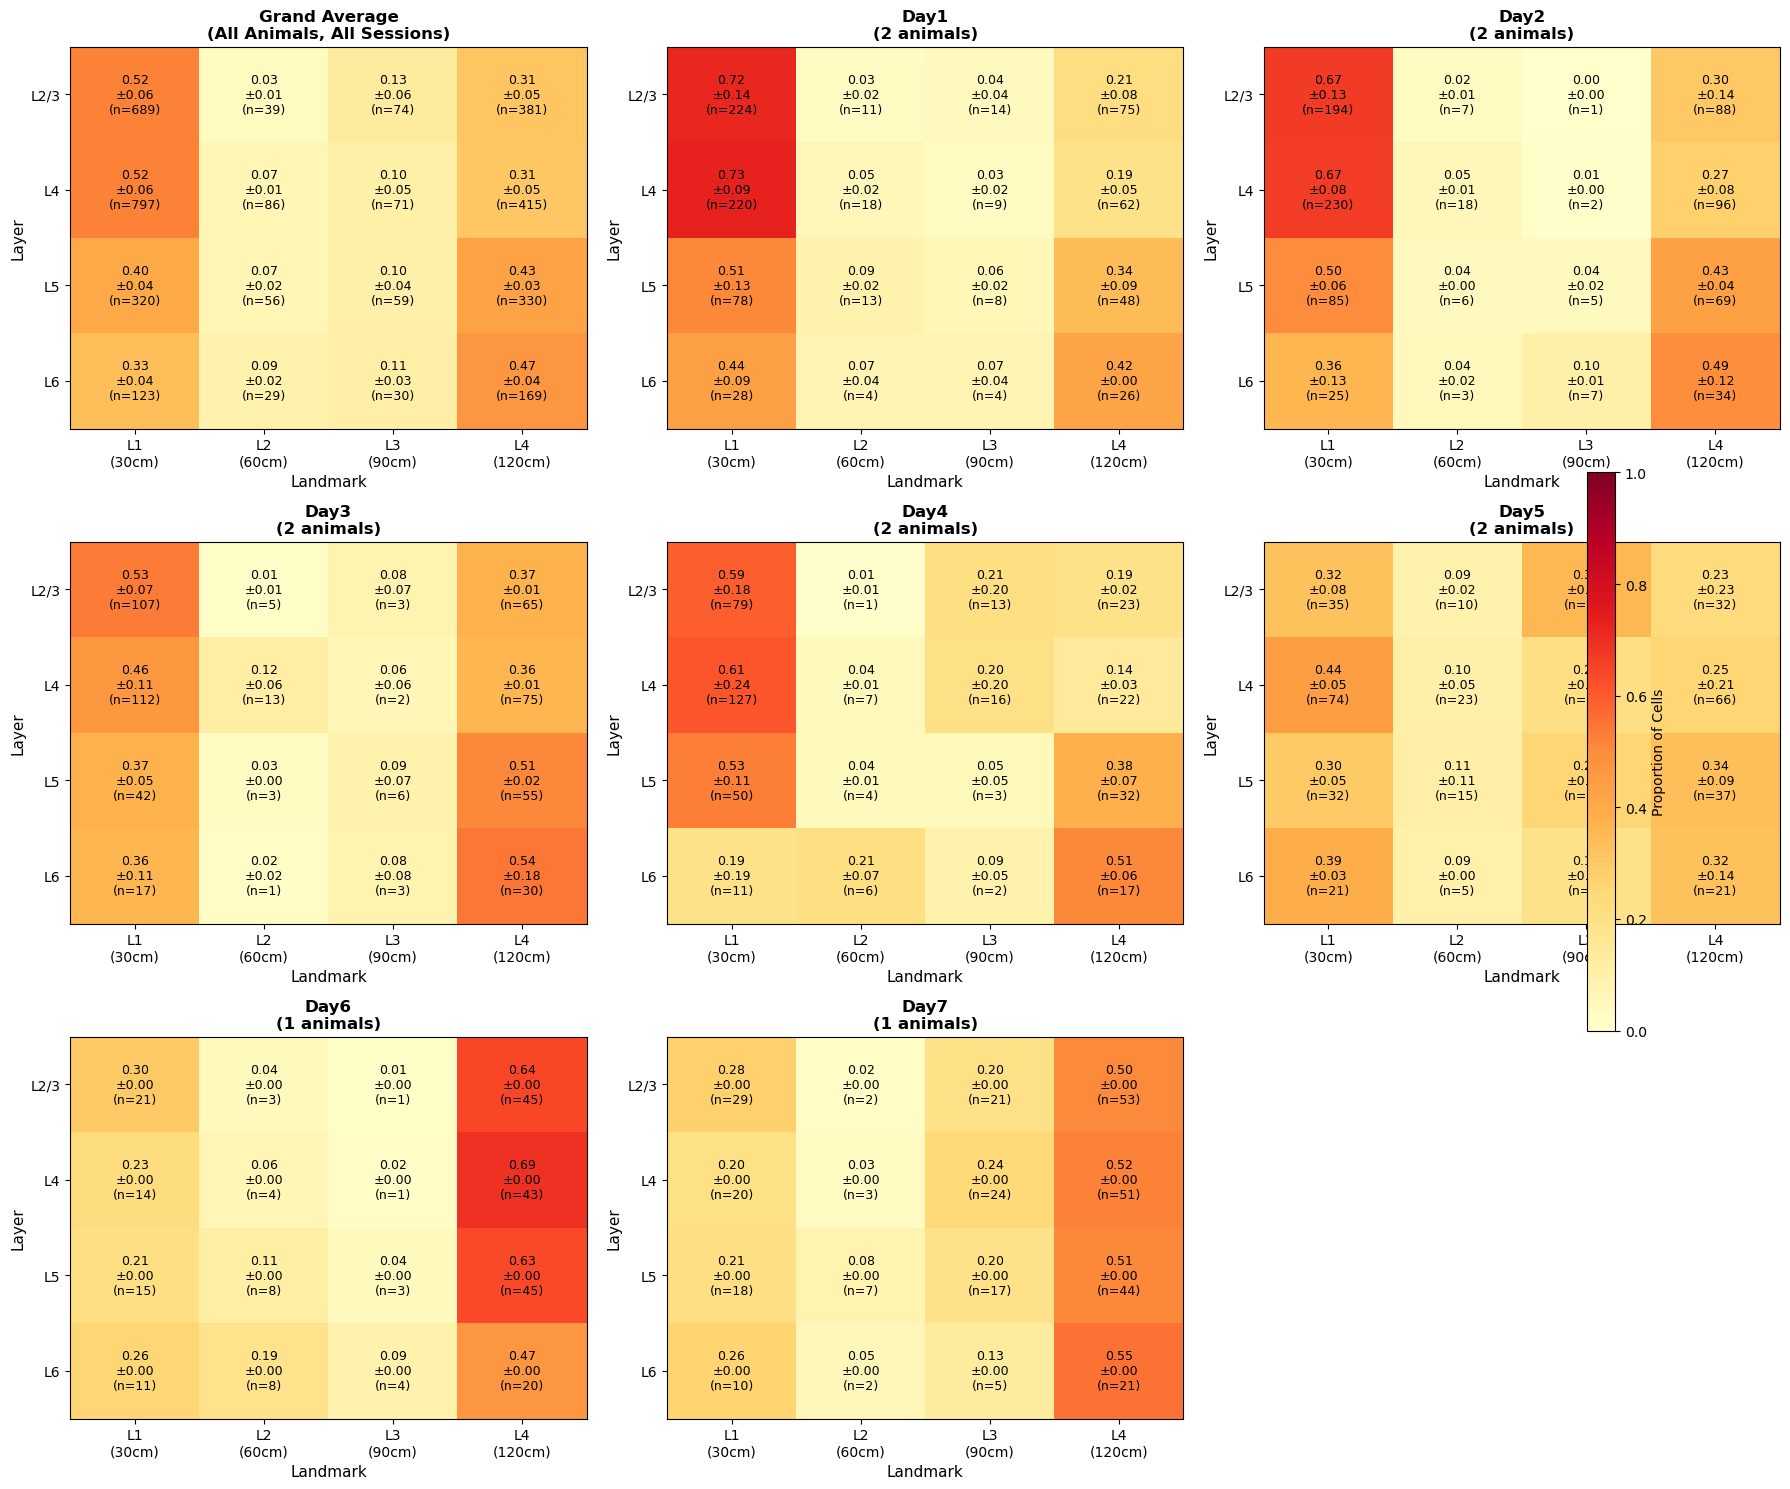


CREATING VIOLIN PLOTS
  Saved: violin_plots_by_layer.png


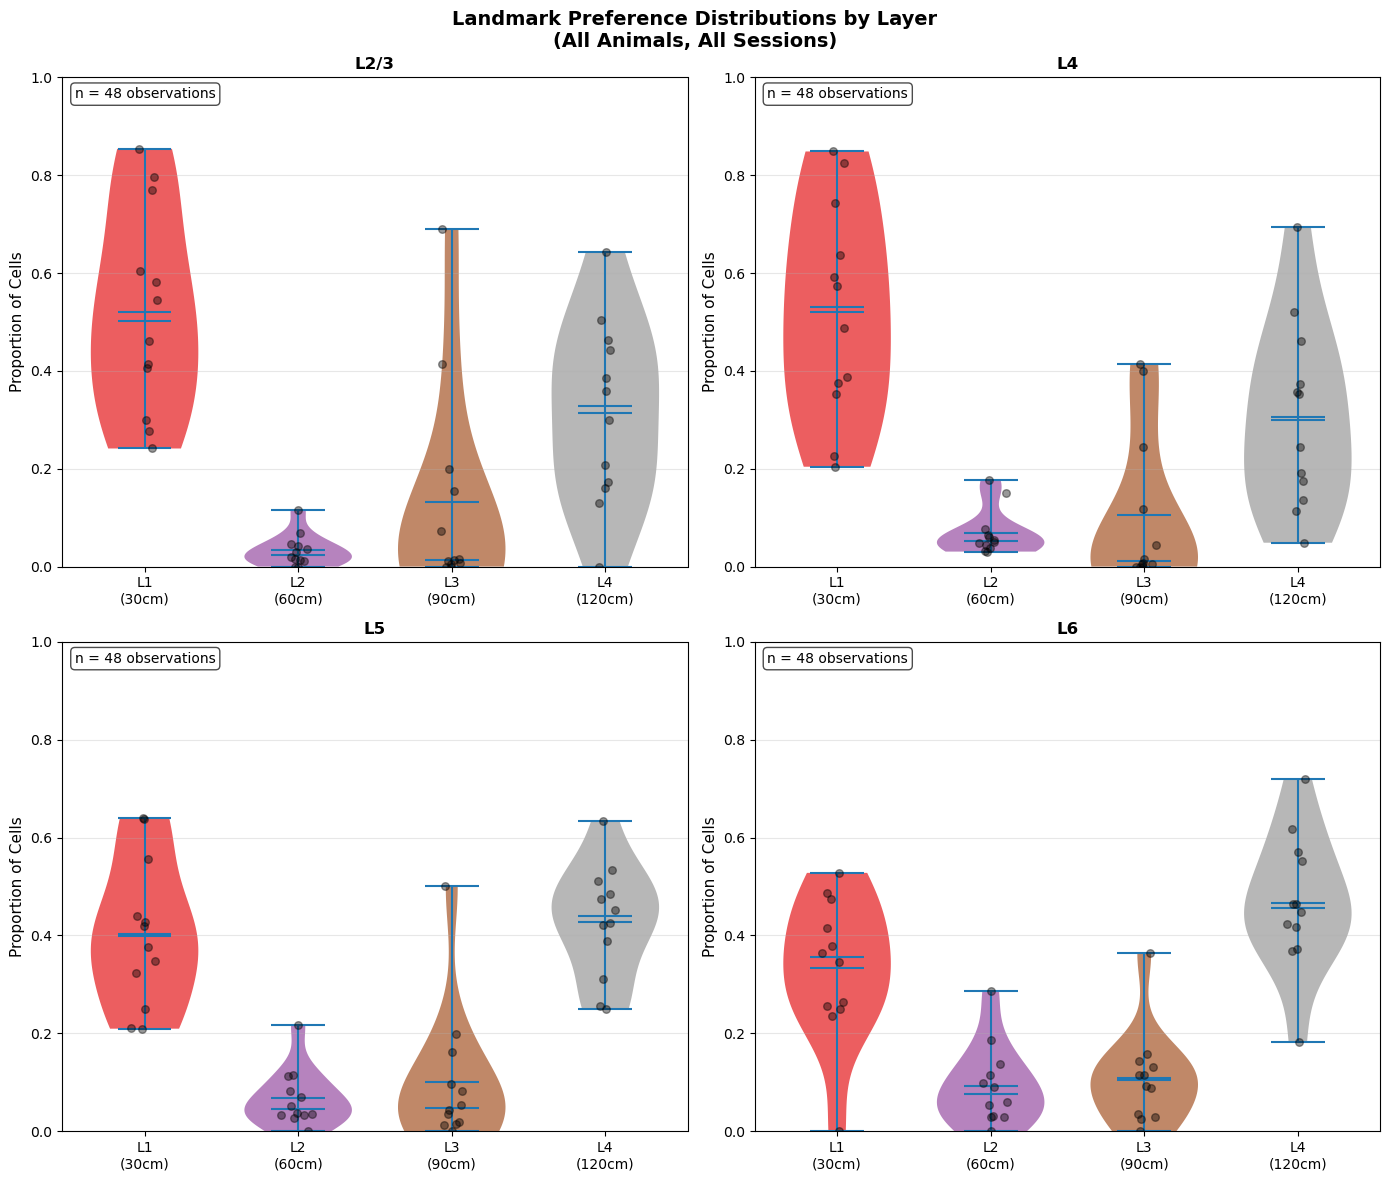


EXPORTING COMBINED SPATIAL DATA

Processing Day1...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 71 and the array at index 1 has size 13

In [4]:

# Configure paths
parent_dir = r"D:\V1_SpatialModulation\2p\V1_prism"
save_dir = r"D:\V1_SpatialModulation\2p\V1_prism\across_animals_analysis"

# Run analysis
results = run_across_animals_analysis(
    parent_dir=parent_dir,
    save_path=save_dir,
    landmark_positions=[30, 60, 90, 120]
)

# Access results
if results:
    print("\n" + "="*80)
    print("RESULTS SUMMARY")
    print("="*80)
    
    metadata = results['metadata']
    print(f"\nAnimals analyzed: {metadata['n_animals']}")
    for animal_id in metadata['animals']:
        sessions = metadata['sessions_per_animal'][animal_id]
        print(f"  {animal_id}: {sessions}")
    
    print(f"\nCombined spatial data available for sessions:")
    for session_id in results['combined_spatial'].keys():
        print(f"  {session_id}:")
        for layer_name, layer_data in results['combined_spatial'][session_id].items():
            print(f"    {layer_name}: {layer_data['n_cells']} cells from {layer_data['n_animals']} animals")
    
    print("\n" + "="*80)
    print("NEXT STEPS")
    print("="*80)
    print("\n1. Use your existing visualization script to create neural response plots")
    print("   Load from: combined_spatial_data_across_animals.h5")
    print("\n2. Example code to load combined data:")
    print("""
          
    import h5py
    
    with h5py.File('combined_spatial_data_across_animals.h5', 'r') as f:
        # Access Day1, L2/3 data
        day1_l23 = f['Day1']['L2_3']
        activity = day1_l23['normalized_spatial_activity'][:]
        bin_centers = day1_l23['bin_centers'][:]
        reliable_cells = day1_l23['reliable_cells'][:]
        
        # Use with your existing visualization script
        # create_response_plot(activity, reliable_cells)
        """)
    print("="*80)